# Notebook 03 — Cross-Source Metadata Enrichment Analysis

## Objective

Use DOI overlap between OpenAlex, Crossref, and Local to decide **how to handle missing values**:

1. How many DOIs are shared across sources?
2. For shared DOIs, which fields can Crossref / Local fill when OpenAlex is empty?
3. How do enrichment opportunities vary by **publication type**?
4. How do they vary by **institution / repository**?
5. What is the practical enrichment rule set for the pipeline?

## Policy (from docs)

- **OpenAlex = source of truth** for identity, title, authors, year, publisher, topics, citations, OA.
- **Crossref enriches:** ISSN, volume, issue, page, event, funding, license, references, abstract, ORCID.
- **Local contributes:** repository coverage, keywords/abstracts for local-only works, institute provenance.

**Outputs:** `./outputs/notebook03/*.csv`


## 1. Imports & setup


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("./outputs/notebook03")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load data


In [2]:
openalex_df = pd.read_csv(DATA_DIR / "raw/open-alex/open_alex.csv", low_memory=False)
crossref_df = pd.read_csv(
    DATA_DIR / "processed/crossref_clean_2016_2026_enriched.csv", low_memory=False
)
local_df = pd.read_csv(
    DATA_DIR / "raw/open-alex/repositories_combined.csv", low_memory=False
)

local_df["publication_year"] = pd.to_numeric(local_df["publication_year"], errors="coerce")
local_df = local_df[local_df["publication_year"] >= 2016].copy()

print("OpenAlex:", openalex_df.shape)
print("Crossref:", crossref_df.shape)
print("Local   :", local_df.shape)


OpenAlex: (73289, 34)
Crossref: (65946, 55)
Local   : (60812, 19)


## 3. Normalize DOIs & publication types


In [3]:
MISSING_TOKENS = {"", " ", "nan", "none", "null", "[]", "{}", "n/a", "na"}


def is_missing(v) -> bool:
    if pd.isna(v):
        return True
    return str(v).strip().lower() in MISSING_TOKENS


def is_present_series(s: pd.Series) -> pd.Series:
    return ~s.map(is_missing)


def normalize_doi(x):
    if pd.isna(x):
        return None
    x = str(x).lower().strip()
    for p in ("https://doi.org/", "http://doi.org/", "doi:"):
        x = x.replace(p, "")
    x = x.strip()
    return x if x and x not in MISSING_TOKENS else None


TYPE_MAP = {
    "article": "journal_article",
    "journal-article": "journal_article",
    "journal article": "journal_article",
    "conference-paper": "conference_paper",
    "proceedings-article": "conference_paper",
    "conference-full-text": "conference_paper",
    "conference-abstract": "conference_abstract",
    "conference-extended-abstract": "conference_abstract",
    "book-chapter": "book_chapter",
    "book": "book",
    "monograph": "book",
    "edited-book": "book",
    "preprint": "preprint",
    "posted-content": "preprint",
    "review": "review",
    "dataset": "dataset",
    "thesis": "thesis",
    "dissertation": "thesis",
    "thesis-full-text": "thesis",
    "thesis-abstract": "thesis",
    "report": "report",
    "other": "other",
}


def canonical_type(x):
    if pd.isna(x):
        return "unknown"
    key = str(x).lower().strip().replace("_", "-")
    key = re.sub(r"\s+", " ", key)
    return TYPE_MAP.get(key) or TYPE_MAP.get(key.replace(" ", "-")) or "other"


openalex_df["doi_norm"] = openalex_df["doi"].map(normalize_doi)
crossref_df["doi_norm"] = crossref_df["DOI"].map(normalize_doi)
local_df["doi_norm"] = local_df["doi"].map(normalize_doi)

openalex_df["canonical_type"] = openalex_df["type"].map(canonical_type)
crossref_df["canonical_type"] = crossref_df["type"].map(canonical_type)
local_df["canonical_type"] = local_df["publication_type"].map(canonical_type)

# Page presence flag for OpenAlex (first_page OR last_page)
openalex_df["has_page_info"] = np.where(
    is_present_series(openalex_df["first_page"]) | is_present_series(openalex_df["last_page"]),
    True,
    np.nan,
)

print("DOI non-null counts:")
print("  OpenAlex", openalex_df["doi_norm"].notna().sum())
print("  Crossref", crossref_df["doi_norm"].notna().sum())
print("  Local   ", local_df["doi_norm"].notna().sum())


DOI non-null counts:
  OpenAlex 71399
  Crossref 65946
  Local    25406


## 4. DOI overlap summary


In [4]:
sources = {
    "OpenAlex": set(openalex_df["doi_norm"].dropna()),
    "Crossref": set(crossref_df["doi_norm"].dropna()),
    "Local": set(local_df["doi_norm"].dropna()),
}

overlap_rows = []
names = list(sources)
for i, a in enumerate(names):
    for b in names[i + 1 :]:
        inter = len(sources[a] & sources[b])
        overlap_rows.append({
            "source_a": a,
            "source_b": b,
            "overlap_dois": inter,
            "pct_of_a": round(100 * inter / len(sources[a]), 2) if sources[a] else 0,
            "pct_of_b": round(100 * inter / len(sources[b]), 2) if sources[b] else 0,
        })

common_all = sources["OpenAlex"] & sources["Crossref"] & sources["Local"]
overlap_summary = pd.DataFrame(overlap_rows)
overlap_summary.loc[len(overlap_summary)] = {
    "source_a": "OpenAlex+Crossref+Local",
    "source_b": "all_three",
    "overlap_dois": len(common_all),
    "pct_of_a": round(100 * len(common_all) / len(sources["OpenAlex"]), 2),
    "pct_of_b": np.nan,
}
overlap_summary.to_csv(OUTPUT_DIR / "doi_overlap_summary.csv", index=False)
overlap_summary


,source_a,source_b,overlap_dois,pct_of_a,pct_of_b
0,OpenAlex,Crossref,65891,92.33,99.92
1,OpenAlex,Local,13710,19.21,55.48
2,Crossref,Local,13693,20.76,55.41
3,OpenAlex+Crossref+Local,all_three,13689,19.18,NaN


In [5]:
all_dois = sources["OpenAlex"] | sources["Crossref"] | sources["Local"]
doi_overlap_df = pd.DataFrame({"doi": list(all_dois)})
doi_overlap_df["openalex_present"] = doi_overlap_df["doi"].isin(sources["OpenAlex"])
doi_overlap_df["crossref_present"] = doi_overlap_df["doi"].isin(sources["Crossref"])
doi_overlap_df["local_present"] = doi_overlap_df["doi"].isin(sources["Local"])


def overlap_category(row):
    parts = []
    if row.openalex_present:
        parts.append("OpenAlex")
    if row.crossref_present:
        parts.append("Crossref")
    if row.local_present:
        parts.append("Local")
    return "+".join(parts)


doi_overlap_df["overlap_category"] = doi_overlap_df.apply(overlap_category, axis=1)
cat_counts = doi_overlap_df["overlap_category"].value_counts().rename_axis(
    "overlap_category"
).reset_index(name="doi_count")
cat_counts.to_csv(OUTPUT_DIR / "doi_overlap_category_counts.csv", index=False)
cat_counts


,overlap_category,doi_count
0,OpenAlex+Crossref,52202
1,OpenAlex+Crossref+Local,13689
2,Local,10996
3,OpenAlex,5455
4,Crossref,51
5,OpenAlex+Local,21
6,Crossref+Local,4


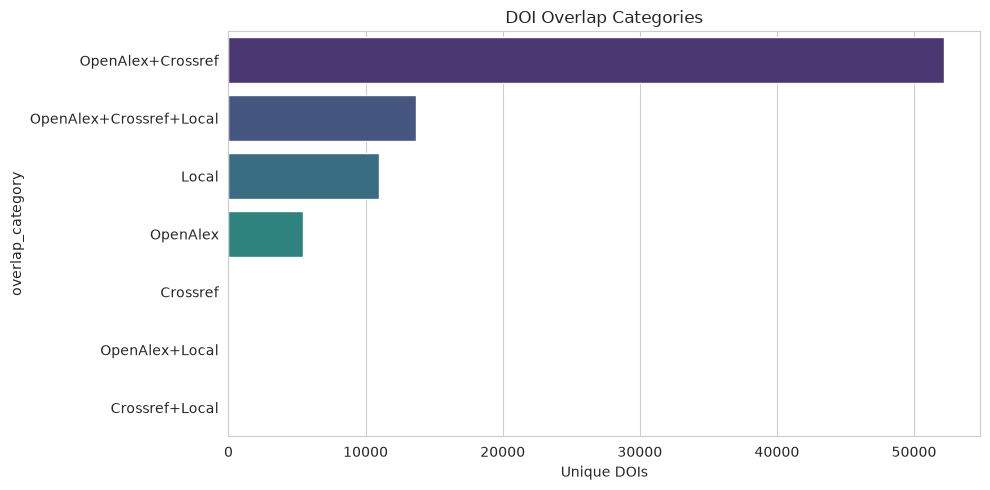

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cat_counts, x="doi_count", y="overlap_category", ax=ax, palette="viridis")
ax.set_title("DOI Overlap Categories")
ax.set_xlabel("Unique DOIs")
plt.tight_layout()
plt.show()


## 5. Type distribution within each source


In [7]:
def type_distribution(df, name):
    out = (
        df.groupby("canonical_type")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    out["dataset"] = name
    out["pct"] = (100 * out["count"] / out["count"].sum()).round(2)
    return out


type_dist = pd.concat([
    type_distribution(openalex_df, "OpenAlex"),
    type_distribution(crossref_df, "Crossref"),
    type_distribution(local_df, "Local"),
], ignore_index=True)
type_dist.to_csv(OUTPUT_DIR / "canonical_type_distribution.csv", index=False)
type_dist.head(30)


,canonical_type,count,dataset,pct
0,journal_article,47202,OpenAlex,64.41
1,conference_paper,11636,OpenAlex,15.88
2,preprint,4896,OpenAlex,6.68
3,book_chapter,3050,OpenAlex,4.16
4,other,1850,OpenAlex,2.52
5,report,1554,OpenAlex,2.12
6,conference_abstract,1118,OpenAlex,1.53
7,review,964,OpenAlex,1.32
8,dataset,792,OpenAlex,1.08
9,book,178,OpenAlex,0.24


## 6. Type-wise DOI overlap (OpenAlex backbone)


In [8]:
# Prefer OpenAlex type when available, else Crossref, else Local
oa_type = openalex_df.dropna(subset=["doi_norm"])[["doi_norm", "canonical_type"]].drop_duplicates("doi_norm")
cr_type = crossref_df.dropna(subset=["doi_norm"])[["doi_norm", "canonical_type"]].drop_duplicates("doi_norm")
local_type = local_df.dropna(subset=["doi_norm"])[["doi_norm", "canonical_type"]].drop_duplicates("doi_norm")

type_lookup = (
    oa_type.merge(cr_type, on="doi_norm", how="outer", suffixes=("_oa", "_cr"))
    .merge(local_type, on="doi_norm", how="outer")
    .rename(columns={"canonical_type": "canonical_type_local"})
)
type_lookup["canonical_type"] = (
    type_lookup["canonical_type_oa"]
    .fillna(type_lookup["canonical_type_cr"])
    .fillna(type_lookup["canonical_type_local"])
)

doi_overlap_typed = doi_overlap_df.merge(
    type_lookup[["doi_norm", "canonical_type"]],
    left_on="doi",
    right_on="doi_norm",
    how="left",
)

type_overlap_analysis = (
    doi_overlap_typed.groupby("canonical_type")
    .agg(
        total_dois=("doi", "count"),
        openalex_dois=("openalex_present", "sum"),
        crossref_dois=("crossref_present", "sum"),
        local_dois=("local_present", "sum"),
    )
    .reset_index()
)
type_overlap_analysis["openalex_coverage_pct"] = (
    100 * type_overlap_analysis["openalex_dois"] / type_overlap_analysis["total_dois"]
).round(2)
type_overlap_analysis["crossref_coverage_pct"] = (
    100 * type_overlap_analysis["crossref_dois"] / type_overlap_analysis["total_dois"]
).round(2)
type_overlap_analysis["local_coverage_pct"] = (
    100 * type_overlap_analysis["local_dois"] / type_overlap_analysis["total_dois"]
).round(2)

type_overlap_analysis.to_csv(OUTPUT_DIR / "publication_type_overlap_analysis.csv", index=False)
doi_overlap_typed.to_csv(OUTPUT_DIR / "doi_overlap_master.csv", index=False)
type_overlap_analysis.sort_values("total_dois", ascending=False)


,canonical_type,total_dois,openalex_dois,crossref_dois,local_dois,openalex_coverage_pct,crossref_coverage_pct,local_coverage_pct
5,journal_article,55933,46259,44218,20313,82.70,79.06,36.32
3,conference_paper,11950,11224,10745,3171,93.92,89.92,26.54
7,preprint,4452,4447,4242,13,99.89,95.28,0.29
1,book_chapter,3048,3023,2998,67,99.18,98.36,2.20
6,other,2038,1820,1394,339,89.30,68.40,16.63
8,report,1538,1538,70,0,100.00,4.55,0.00
2,conference_abstract,1497,1113,1070,690,74.35,71.48,46.09
9,review,942,942,923,97,100.00,97.98,10.30
4,dataset,792,792,115,0,100.00,14.52,0.00
0,book,180,171,148,10,95.00,82.22,5.56


## 7. Collapse Crossref to one row per DOI


In [9]:
def first_non_missing(series):
    for v in series:
        if not is_missing(v):
            return v
    return np.nan


# Scalar bibliographic fields to keep
CR_KEEP = [
    "doi_norm", "canonical_type", "title", "abstract", "publisher", "container-title",
    "ISSN", "volume", "issue", "page", "article-number",
    "is-referenced-by-count", "reference-count", "references_json",
    "license_URL", "language", "URL",
    "author_name", "author_affiliation", "author_ORCID",
    "funder_name", "funder_DOI", "funder_award",
    "event.name", "event.location", "event.acronym", "event.sponsor",
]
CR_KEEP = [c for c in CR_KEEP if c in crossref_df.columns]

cr_one = (
    crossref_df.dropna(subset=["doi_norm"])
    .sort_values("doi_norm")
    .groupby("doi_norm", as_index=False)[CR_KEEP]
    .agg(first_non_missing)
)
print("Crossref unique DOIs:", len(cr_one))
cr_one.head(3)


Crossref unique DOIs: 65946


,doi_norm,canonical_type,title,abstract,publisher,container-title,ISSN,volume,issue,page,article-number,is-referenced-by-count,reference-count,references_json,license_URL,language,URL,author_name,author_affiliation,author_ORCID,funder_name,funder_DOI,funder_award,event.name,event.location,event.acronym,event.sponsor
0,10.1001/jama.2018.10060,journal_article,"Global Mortality From Firearms, 1990-2016",NaN,American Medical Association (AMA),JAMA,0098-7484,320,8,792,NaN,251,40,"[{""key"": ""joi180081r3"", ""doi-asserted-by"": ""pu...",NaN,en,https://doi.org/10.1001/jama.2018.10060,Mohsen Naghavi; Laurie B. Marczak; Michael Kut...,"Institute for Health Metrics and Evaluation, U...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.1001/jama.2018.10359,journal_article,Fixed Low-Dose Triple Combination Antihyperten...,NaN,American Medical Association (AMA),JAMA,0098-7484,320,6,566,NaN,189,39,"[{""issue"": ""10100"", ""key"": ""joi180083r1"", ""doi...",NaN,en,https://doi.org/10.1001/jama.2018.10359,Ruth Webster; Abdul Salam; H. Asita de Silva; ...,"The George Institute for Global Health, Univer...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10.1001/jama.2018.6229,journal_article,Association of the Quick Sequential (Sepsis-Re...,NaN,American Medical Association (AMA),JAMA,0098-7484,319,21,2202,NaN,175,25,"[{""issue"": ""8"", ""key"": ""joi180052r1"", ""doi-ass...",NaN,en,https://doi.org/10.1001/jama.2018.6229,Kristina E. Rudd; Christopher W. Seymour; Adam...,Department of Medicine and the International R...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Build common-DOI enrichment table (OpenAlex ⨝ Crossref)

For each enrichment field, count how many common DOIs have:
- OpenAlex missing + Crossref present (**fillable**)
- both present
- only OpenAlex
- neither


In [10]:
# OpenAlex side: one row per DOI
OA_KEEP = [
    "doi_norm", "canonical_type", "title", "publisher", "source_name",
    "issn_l", "volume", "issue", "has_page_info",
    "cited_by_count", "referenced_works_count", "license",
    "landing_page_url", "pdf_url", "language",
    "sri_lankan_institutions", "authors", "type",
]
OA_KEEP = [c for c in OA_KEEP if c in openalex_df.columns]
oa_one = openalex_df.dropna(subset=["doi_norm"]).drop_duplicates("doi_norm")[OA_KEEP].copy()

common = sources["OpenAlex"] & sources["Crossref"]
oa_common = oa_one[oa_one["doi_norm"].isin(common)].copy()
cr_common = cr_one[cr_one["doi_norm"].isin(common)].copy()

merged = oa_common.merge(cr_common, on="doi_norm", suffixes=("_oa", "_cr"))
print("Merged common DOIs:", merged.shape)


Merged common DOIs: (65891, 44)


In [11]:
# Field pairs: (label, openalex_col, crossref_col)
ENRICH_PAIRS = [
    ("abstract", None, "abstract"),
    ("orcid", None, "author_ORCID"),
    ("license", "license", "license_URL"),
    ("issn", "issn_l", "ISSN"),
    ("volume", "volume", "volume"),
    ("issue", "issue", "issue"),
    ("page", "has_page_info", "page"),
    ("article_number", None, "article-number"),
    ("journal", "source_name", "container-title"),
    ("publisher", "publisher", "publisher"),
    ("funding", None, "funder_name"),
    ("event_name", None, "event.name"),
    ("references", None, "references_json"),
    ("reference_count", "referenced_works_count", "reference-count"),
    ("citation_count", "cited_by_count", "is-referenced-by-count"),
    ("author_affiliation", "sri_lankan_institutions", "author_affiliation"),
]


def resolve(col, suffix):
    if col is None:
        return None
    if col + suffix in merged.columns:
        return col + suffix
    if col in merged.columns:
        return col
    return None


enrichment_rows = []
for label, oa_col, cr_col in ENRICH_PAIRS:
    oa_r = resolve(oa_col, "_oa")
    cr_r = resolve(cr_col, "_cr")
    if cr_r is None and oa_r is None:
        continue

    if oa_r is None:
        oa_miss = pd.Series(True, index=merged.index)
        oa_cov = 0.0
    else:
        oa_miss = merged[oa_r].map(is_missing)
        oa_cov = round(100 * (~oa_miss).mean(), 2)

    if cr_r is None:
        cr_pres = pd.Series(False, index=merged.index)
        cr_cov = 0.0
    else:
        cr_pres = ~merged[cr_r].map(is_missing)
        cr_cov = round(100 * cr_pres.mean(), 2)

    fillable = int((oa_miss & cr_pres).sum())
    both = int((~oa_miss & cr_pres).sum()) if oa_r is not None else 0
    oa_only = int((~oa_miss & ~cr_pres).sum()) if oa_r is not None else 0
    neither = int((oa_miss & ~cr_pres).sum())

    enrichment_rows.append({
        "field": label,
        "oa_coverage_pct": oa_cov,
        "cr_coverage_pct": cr_cov,
        "fillable_oa_missing_cr_present": fillable,
        "fillable_pct_of_common": round(100 * fillable / len(merged), 2),
        "both_present": both,
        "oa_only": oa_only,
        "neither": neither,
        "recommended_action": (
            "enrich_from_crossref" if fillable > 0 and (oa_r is None or cr_cov > oa_cov)
            else "keep_openalex" if oa_cov >= cr_cov
            else "prefer_crossref_if_richer"
        ),
    })

enrichment_matrix = pd.DataFrame(enrichment_rows).sort_values(
    "fillable_oa_missing_cr_present", ascending=False
)
enrichment_matrix.to_csv(OUTPUT_DIR / "enrichment_opportunity_matrix.csv", index=False)
enrichment_matrix


,field,oa_coverage_pct,cr_coverage_pct,fillable_oa_missing_cr_present,fillable_pct_of_common,both_present,oa_only,neither,recommended_action
12,references,0.00,59.69,39333,59.69,0,0,26558,enrich_from_crossref
0,abstract,0.00,44.41,29263,44.41,0,0,36628,enrich_from_crossref
9,publisher,57.74,99.99,27838,42.25,38044,4,5,enrich_from_crossref
1,orcid,0.00,32.86,21649,32.86,0,0,44242,enrich_from_crossref
2,license,47.88,61.06,19919,30.23,20313,11236,14423,enrich_from_crossref
10,funding,0.00,16.25,10705,16.25,0,0,55186,enrich_from_crossref
8,journal,82.98,94.32,10184,15.46,51962,2712,1033,enrich_from_crossref
7,article_number,0.00,15.39,10143,15.39,0,0,55748,enrich_from_crossref
11,event_name,0.00,14.41,9496,14.41,0,0,56395,enrich_from_crossref
6,page,82.74,76.88,90,0.14,50566,3949,11286,keep_openalex


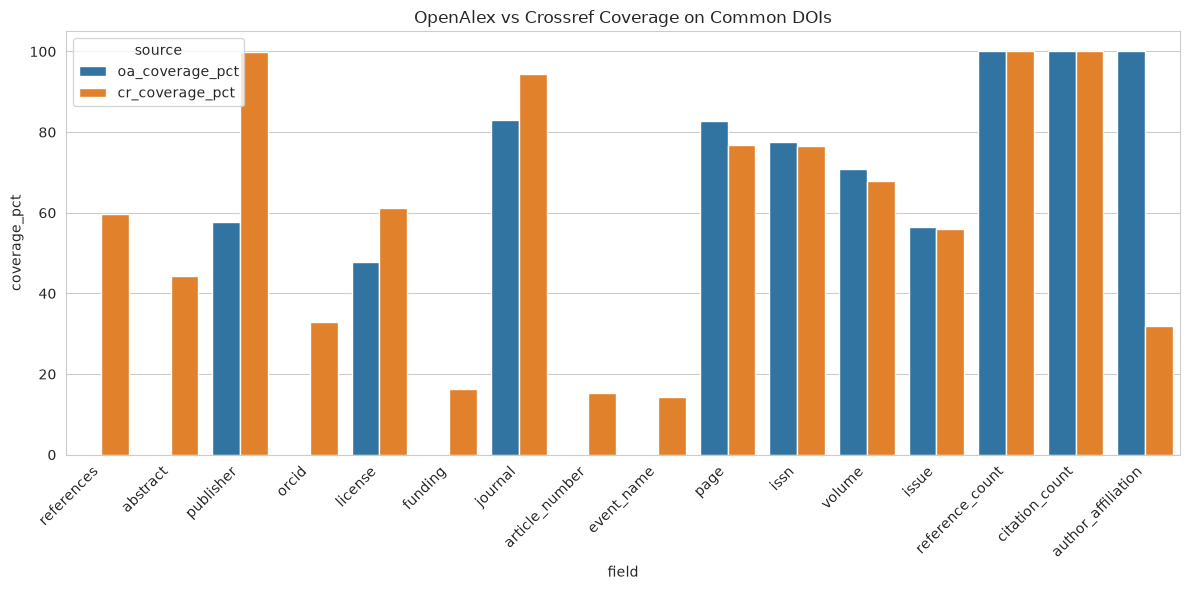

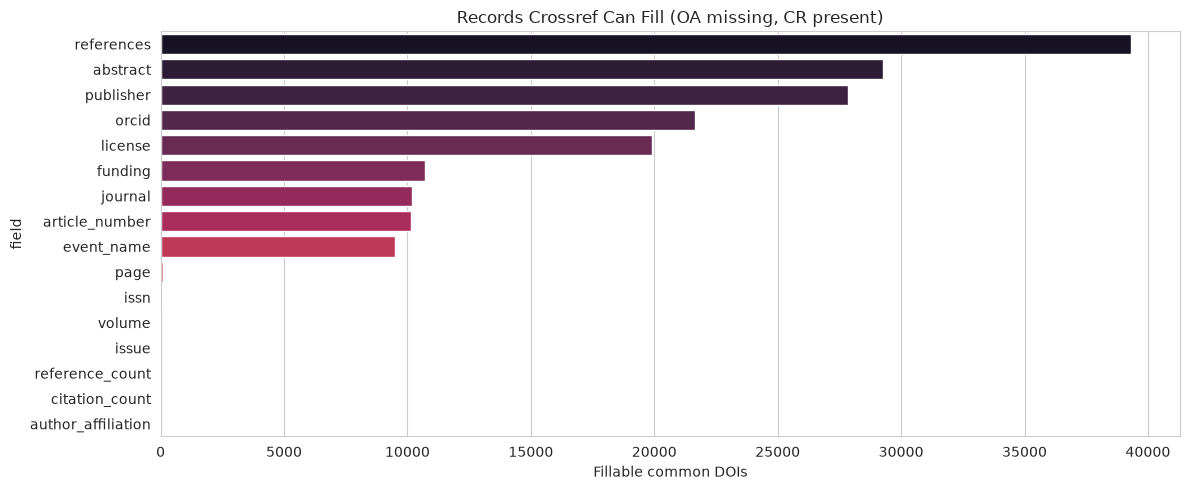

In [12]:
plot_df = enrichment_matrix.melt(
    id_vars="field",
    value_vars=["oa_coverage_pct", "cr_coverage_pct"],
    var_name="source",
    value_name="coverage_pct",
)
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="field", y="coverage_pct", hue="source")
plt.xticks(rotation=45, ha="right")
plt.title("OpenAlex vs Crossref Coverage on Common DOIs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=enrichment_matrix,
    x="fillable_oa_missing_cr_present",
    y="field",
    palette="rocket",
)
plt.title("Records Crossref Can Fill (OA missing, CR present)")
plt.xlabel("Fillable common DOIs")
plt.tight_layout()
plt.show()


## 9. Type-wise enrichment opportunities

For each publication type, measure fillable counts for key Crossref fields.


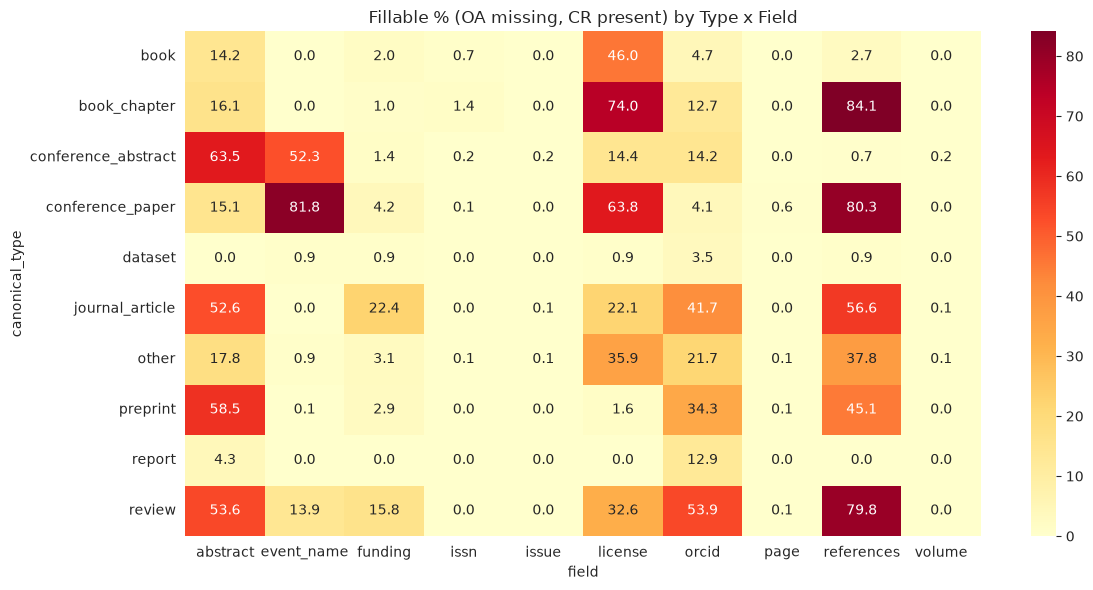

,canonical_type,records,field,fillable,fillable_pct,cr_coverage_pct
0,book,148,abstract,21,14.19,14.19
1,book,148,orcid,7,4.73,4.73
2,book,148,issn,1,0.68,24.32
3,book,148,volume,0,0.00,0.00
4,book,148,issue,0,0.00,0.00
5,book,148,page,0,0.00,0.00
6,book,148,funding,3,2.03,2.03
7,book,148,license,68,45.95,48.65
8,book,148,event_name,0,0.00,0.00
9,book,148,references,4,2.70,2.70


In [13]:
TYPE_ENRICH_FIELDS = [
    ("abstract", None, "abstract"),
    ("orcid", None, "author_ORCID"),
    ("issn", "issn_l", "ISSN"),
    ("volume", "volume", "volume"),
    ("issue", "issue", "issue"),
    ("page", "has_page_info", "page"),
    ("funding", None, "funder_name"),
    ("license", "license", "license_URL"),
    ("event_name", None, "event.name"),
    ("references", None, "references_json"),
]

type_enrich_rows = []
for ctype, group in merged.groupby("canonical_type_oa"):
    if len(group) < 30:
        continue
    for label, oa_col, cr_col in TYPE_ENRICH_FIELDS:
        oa_r = resolve(oa_col, "_oa")
        cr_r = resolve(cr_col, "_cr")
        if cr_r is None:
            continue
        oa_miss = (
            pd.Series(True, index=group.index)
            if oa_r is None
            else group[oa_r].map(is_missing)
        )
        cr_pres = ~group[cr_r].map(is_missing)
        fillable = int((oa_miss & cr_pres).sum())
        type_enrich_rows.append({
            "canonical_type": ctype,
            "records": len(group),
            "field": label,
            "fillable": fillable,
            "fillable_pct": round(100 * fillable / len(group), 2),
            "cr_coverage_pct": round(100 * cr_pres.mean(), 2),
        })

type_enrichment = pd.DataFrame(type_enrich_rows)
type_enrichment.to_csv(OUTPUT_DIR / "enrichment_by_publication_type.csv", index=False)

# Heatmap of fillable %
if not type_enrichment.empty:
    mat = type_enrichment.pivot(
        index="canonical_type", columns="field", values="fillable_pct"
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(mat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
    ax.set_title("Fillable % (OA missing, CR present) by Type x Field")
    plt.tight_layout()
    plt.show()

type_enrichment.head(40)


## 10. Institute-wise enrichment (OpenAlex institutions on common DOIs)

Shows which Sri Lankan institutions benefit most from Crossref fills.


In [14]:
INST_FIELDS = ["abstract", "orcid", "issn", "volume", "funding", "license", "references"]


def explode_institutions(df, inst_col="sri_lankan_institutions"):
    rows = []
    for idx, val in df[inst_col].astype(str).items():
        if val.lower() in {"nan", "none", "null", ""}:
            continue
        for part in re.split(r"[;|]", val):
            part = part.strip()
            if part:
                rows.append((idx, part))
    if not rows:
        return pd.DataFrame(columns=["idx", "institution"])
    return pd.DataFrame(rows, columns=["idx", "institution"])


# Use OA institution column from merged
inst_col = "sri_lankan_institutions" if "sri_lankan_institutions" in merged.columns else "sri_lankan_institutions_oa"
if inst_col not in merged.columns:
    # after merge may be unsuffixed
    candidates = [c for c in merged.columns if "sri_lankan_institutions" in c]
    inst_col = candidates[0] if candidates else None

inst_enrich_rows = []
if inst_col:
    exp = explode_institutions(merged, inst_col)
    top_inst = exp["institution"].value_counts().head(12).index
    exp = exp[exp["institution"].isin(top_inst)]
    for inst, idxs in exp.groupby("institution")["idx"]:
        group = merged.loc[idxs.unique()]
        for label, oa_col, cr_col in TYPE_ENRICH_FIELDS:
            if label not in INST_FIELDS:
                continue
            oa_r = resolve(oa_col, "_oa")
            cr_r = resolve(cr_col, "_cr")
            if cr_r is None:
                continue
            oa_miss = (
                pd.Series(True, index=group.index)
                if oa_r is None
                else group[oa_r].map(is_missing)
            )
            cr_pres = ~group[cr_r].map(is_missing)
            fillable = int((oa_miss & cr_pres).sum())
            inst_enrich_rows.append({
                "institution": inst,
                "records": len(group),
                "field": label,
                "fillable": fillable,
                "fillable_pct": round(100 * fillable / len(group), 2) if len(group) else 0,
            })

inst_enrichment = pd.DataFrame(inst_enrich_rows)
inst_enrichment.to_csv(OUTPUT_DIR / "enrichment_by_institution.csv", index=False)
inst_enrichment.head(30)


,institution,records,field,fillable,fillable_pct
0,Department of Archaeology,2195,abstract,1149,52.35
1,Department of Archaeology,2195,orcid,1034,47.11
2,Department of Archaeology,2195,issn,9,0.41
3,Department of Archaeology,2195,volume,1,0.05
4,Department of Archaeology,2195,funding,691,31.48
5,Department of Archaeology,2195,license,573,26.10
6,Department of Archaeology,2195,references,1520,69.25
7,National Hospital of Sri Lanka,2233,abstract,1049,46.98
8,National Hospital of Sri Lanka,2233,orcid,866,38.78
9,National Hospital of Sri Lanka,2233,issn,0,0.00


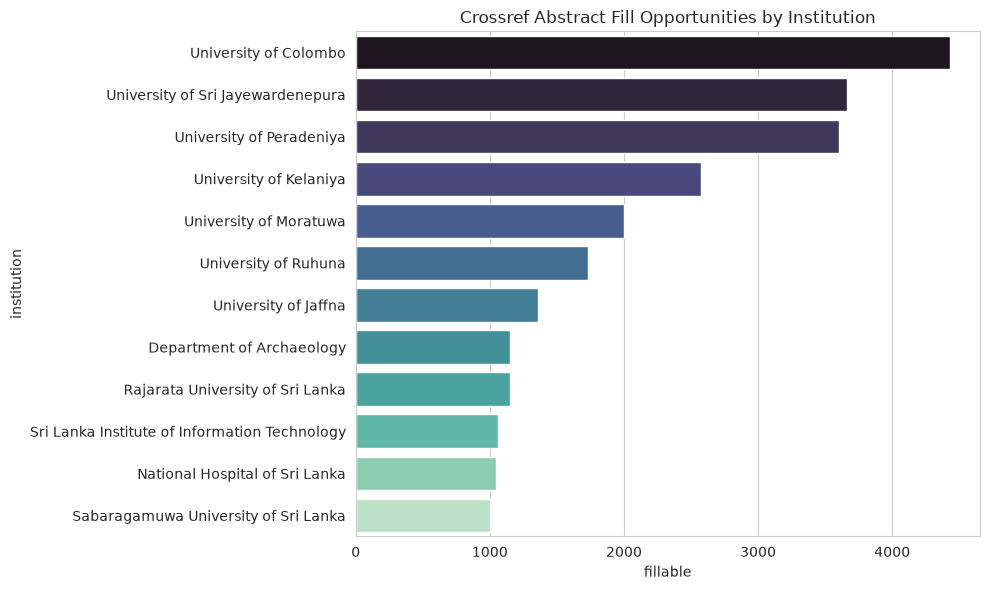

In [15]:
if not inst_enrichment.empty:
    # Focus on abstract fill opportunities by institution
    abs_inst = inst_enrichment[inst_enrichment["field"] == "abstract"].sort_values(
        "fillable", ascending=False
    )
    if not abs_inst.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=abs_inst, x="fillable", y="institution", ax=ax, palette="mako")
        ax.set_title("Crossref Abstract Fill Opportunities by Institution")
        plt.tight_layout()
        plt.show()


## 11. Local repository enrichment vs OpenAlex

For DOIs present in both OpenAlex and Local, can Local fill keywords / abstract?
Also quantify Local-only (no DOI in OA) coverage by repository — needs title matching.


In [16]:
LOCAL_KEEP = [
    "doi_norm", "canonical_type", "title", "abstract", "keywords",
    "authors", "publisher", "journal", "url", "rights", "source_institution_id",
]
LOCAL_KEEP = [c for c in LOCAL_KEEP if c in local_df.columns]
local_one = local_df.dropna(subset=["doi_norm"]).drop_duplicates("doi_norm")[LOCAL_KEEP].copy()

oa_local_common = sources["OpenAlex"] & sources["Local"]
oa_l = oa_one[oa_one["doi_norm"].isin(oa_local_common)].copy()
loc_l = local_one[local_one["doi_norm"].isin(oa_local_common)].copy()
merged_local = oa_l.merge(loc_l, on="doi_norm", suffixes=("_oa", "_local"))
print("OA ∩ Local DOIs:", len(merged_local))

local_pairs = [
    ("abstract", None, "abstract"),
    ("keywords", None, "keywords"),
    ("journal", "source_name", "journal"),
    ("publisher", "publisher", "publisher"),
    ("authors", "authors", "authors"),
    ("url", "landing_page_url", "url"),
]

local_enrich_rows = []
for label, oa_col, loc_col in local_pairs:
    oa_r = oa_col if oa_col in merged_local.columns else (
        oa_col + "_oa" if oa_col and oa_col + "_oa" in merged_local.columns else None
    )
    loc_r = loc_col if loc_col in merged_local.columns else (
        loc_col + "_local" if loc_col + "_local" in merged_local.columns else None
    )
    # after merge with suffixes
    if oa_col and oa_col not in merged_local.columns and f"{oa_col}_oa" in merged_local.columns:
        oa_r = f"{oa_col}_oa"
    if loc_col not in merged_local.columns and f"{loc_col}_local" in merged_local.columns:
        loc_r = f"{loc_col}_local"
    if loc_col in merged_local.columns:
        loc_r = loc_col

    if loc_r is None:
        continue
    oa_miss = pd.Series(True, index=merged_local.index) if oa_r is None else merged_local[oa_r].map(is_missing)
    loc_pres = ~merged_local[loc_r].map(is_missing)
    fillable = int((oa_miss & loc_pres).sum())
    local_enrich_rows.append({
        "field": label,
        "oa_coverage_pct": 0.0 if oa_r is None else round(100 * (~oa_miss).mean(), 2),
        "local_coverage_pct": round(100 * loc_pres.mean(), 2),
        "fillable_oa_missing_local_present": fillable,
        "fillable_pct": round(100 * fillable / len(merged_local), 2),
    })

local_enrichment = pd.DataFrame(local_enrich_rows)
local_enrichment.to_csv(OUTPUT_DIR / "local_enrichment_vs_openalex.csv", index=False)
local_enrichment


OA ∩ Local DOIs: 13710


,field,oa_coverage_pct,local_coverage_pct,fillable_oa_missing_local_present,fillable_pct
0,abstract,0.00,69.82,9573,69.82
1,keywords,0.00,33.25,4558,33.25
2,journal,82.14,65.40,0,0.00
3,publisher,30.22,97.95,9415,68.67
4,authors,100.00,99.93,0,0.00
5,url,100.00,100.00,0,0.00


In [17]:
# Local-only DOIs and no-DOI records by repository
local_only_dois = sources["Local"] - sources["OpenAlex"]
local_has_doi = local_df["doi_norm"].notna()

repo_stats = (
    local_df.assign(
        has_doi=local_has_doi,
        in_openalex=local_df["doi_norm"].isin(sources["OpenAlex"]),
        local_only_doi=local_df["doi_norm"].isin(local_only_dois),
    )
    .groupby("source_institution_id")
    .agg(
        records=("title", "size"),
        with_doi=("has_doi", "sum"),
        matched_openalex=("in_openalex", "sum"),
        local_only_doi=("local_only_doi", "sum"),
    )
    .reset_index()
)
repo_stats["doi_coverage_pct"] = (100 * repo_stats["with_doi"] / repo_stats["records"]).round(2)
repo_stats["no_doi_records"] = repo_stats["records"] - repo_stats["with_doi"]
repo_stats["pct_matched_openalex_of_doi"] = np.where(
    repo_stats["with_doi"] > 0,
    (100 * repo_stats["matched_openalex"] / repo_stats["with_doi"]).round(2),
    0,
)
repo_stats = repo_stats.sort_values("records", ascending=False)
repo_stats.to_csv(OUTPUT_DIR / "local_repository_linkage_stats.csv", index=False)
repo_stats


,source_institution_id,records,with_doi,matched_openalex,local_only_doi,doi_coverage_pct,no_doi_records,pct_matched_openalex_of_doi
7,sljol,18032,18032,9210,8822,100.00,0,51.08
4,ruh,10804,408,335,73,3.78,10396,82.11
9,uom,10339,3235,1933,1302,31.29,7104,59.75
5,seu,4022,185,159,26,4.60,3837,85.95
10,uwu,3812,0,0,0,0.00,3812,0.00
6,sliit,3463,2612,1869,743,75.43,851,71.55
3,pdn,3289,0,0,0,0.00,3289,0.00
1,cmb,2786,934,819,115,33.52,1852,87.69
0,busl,2423,0,0,0,0.00,2423,0.00
2,nsf,1367,0,0,0,0.00,1367,0.00


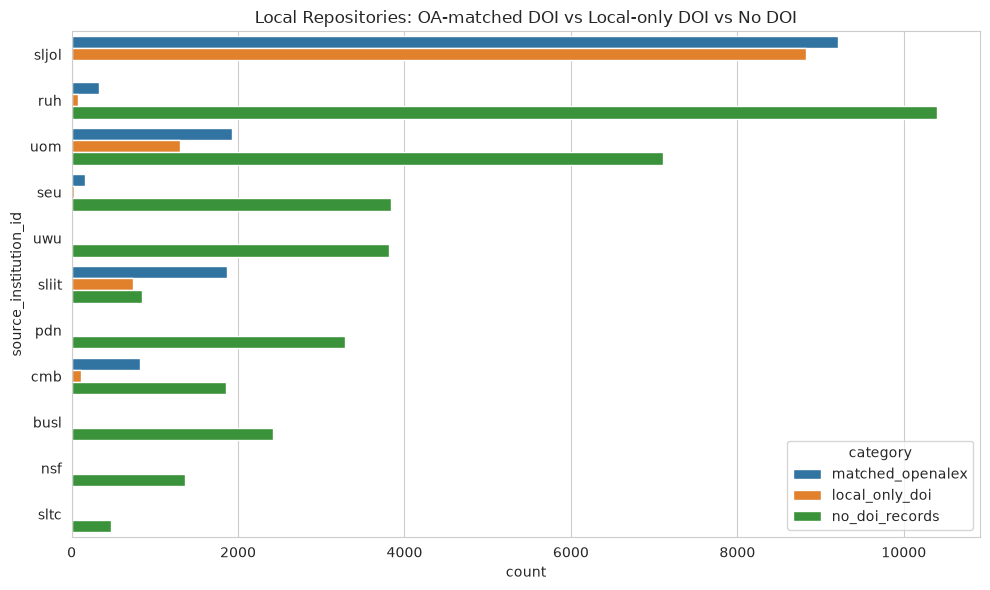

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
plot = repo_stats.melt(
    id_vars="source_institution_id",
    value_vars=["matched_openalex", "local_only_doi", "no_doi_records"],
    var_name="category",
    value_name="count",
)
sns.barplot(data=plot, x="count", y="source_institution_id", hue="category", ax=ax)
ax.set_title("Local Repositories: OA-matched DOI vs Local-only DOI vs No DOI")
plt.tight_layout()
plt.show()


## 12. Final enrichment rule table

Actionable rules for the metadata pipeline.


In [19]:
rules = pd.DataFrame([
    {"field": "doi", "primary": "OpenAlex", "enrich_from": "-", "when": "always keep OA", "notes": "normalize; Local/CR for discovery only"},
    {"field": "title", "primary": "OpenAlex", "enrich_from": "Local/Crossref", "when": "OA missing", "notes": "rare"},
    {"field": "authors", "primary": "OpenAlex", "enrich_from": "Crossref author_name", "when": "OA missing", "notes": "prefer OA structured authors"},
    {"field": "publication_year", "primary": "OpenAlex", "enrich_from": "Crossref", "when": "OA missing", "notes": ""},
    {"field": "publication_type", "primary": "OpenAlex", "enrich_from": "Crossref/Local", "when": "normalize via TYPE_MAP", "notes": "type-aware joins"},
    {"field": "abstract", "primary": "Crossref", "enrich_from": "Local", "when": "OA has none; fill CR then Local", "notes": "see fillable counts"},
    {"field": "author_ORCID", "primary": "Crossref", "enrich_from": "-", "when": "any CR value", "notes": "OA export lacks ORCID"},
    {"field": "issn/volume/issue/page", "primary": "Crossref", "enrich_from": "OpenAlex issn_l/volume/issue/pages", "when": "OA missing venue fields", "notes": "journal articles"},
    {"field": "funding", "primary": "Crossref", "enrich_from": "-", "when": "funder_name present", "notes": "OA export lacks funders"},
    {"field": "license", "primary": "OpenAlex license", "enrich_from": "Crossref license_URL", "when": "OA missing", "notes": ""},
    {"field": "event.*", "primary": "Crossref", "enrich_from": "-", "when": "conference types", "notes": "proceedings-article"},
    {"field": "references", "primary": "Crossref", "enrich_from": "-", "when": "references_json present", "notes": "OA has counts only"},
    {"field": "citation_count", "primary": "OpenAlex cited_by_count", "enrich_from": "CR is-referenced-by-count", "when": "store both + divergence flag", "notes": "do not overwrite blindly"},
    {"field": "topics/concepts", "primary": "OpenAlex", "enrich_from": "-", "when": "always", "notes": ""},
    {"field": "keywords", "primary": "Local", "enrich_from": "-", "when": "OA/CR missing", "notes": "repo-native"},
    {"field": "institution", "primary": "OpenAlex sri_lankan_institutions", "enrich_from": "Local source_institution_id", "when": "provenance / no-DOI works", "notes": "Local is repository id"},
    {"field": "no-DOI local works", "primary": "Local", "enrich_from": "title match to OA/CR", "when": "doi missing", "notes": "especially theses"},
])
rules.to_csv(OUTPUT_DIR / "final_enrichment_rules.csv", index=False)
rules


,field,primary,enrich_from,when,notes
0,doi,OpenAlex,-,always keep OA,normalize; Local/CR for discovery only
1,title,OpenAlex,Local/Crossref,OA missing,rare
2,authors,OpenAlex,Crossref author_name,OA missing,prefer OA structured authors
3,publication_year,OpenAlex,Crossref,OA missing,
4,publication_type,OpenAlex,Crossref/Local,normalize via TYPE_MAP,type-aware joins
5,abstract,Crossref,Local,OA has none; fill CR then Local,see fillable counts
6,author_ORCID,Crossref,-,any CR value,OA export lacks ORCID
7,issn/volume/issue/page,Crossref,OpenAlex issn_l/volume/issue/pages,OA missing venue fields,journal articles
8,funding,Crossref,-,funder_name present,OA export lacks funders
9,license,OpenAlex license,Crossref license_URL,OA missing,


## 13. Key takeaways — using metadata effectively

1. **Join key:** normalized DOI for OpenAlex ↔ Crossref; Local joins on DOI when present,
   else title (+ year/type) matching for no-DOI repository records.
2. **Fill order for missing values:** keep OpenAlex core fields → fill venue/rights/funding/abstract/ORCID
   from Crossref on common DOIs → fill keywords/abstract gaps from Local → retain Local-only
   repository records as first-class works.
3. **Type-aware:** enrich ISSN/volume/issue/page mainly for `journal_article`; use `event.*`
   for `conference_paper`; do not expect DOIs for many Local theses.
4. **Institute-aware:** repositories with low DOI coverage need title-based enrichment first;
   OpenAlex institutions with high Crossref overlap get the largest abstract/ORCID/funding fills.
5. **Do not overwrite:** citations, titles, authors, publisher — keep OpenAlex; store Crossref
   citation counts separately if divergence analysis is needed.
6. **Next engineering step:** implement the rule table as a merge/enrichment script producing
   one canonical publication record per work.
